# Assignment 1

![Assignment 1](assets/assn1.png)

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [28]:
def glcm_y(image):
    glcm = np.zeros((256, 256), dtype=int)
    h, w = image.shape
    for y in range(h - 1): 
        for x in range(w):
            i = image[y, x]
            j = image[y + 1, x]
            glcm[i, j] += 1       
    return glcm

def glcm_x(image):
    glcm = np.zeros((256, 256), dtype=int)
    h, w = image.shape
    for y in range(h): 
        for x in range(w - 1):
            i = image[y, x]
            j = image[y, x + 1]
            glcm[i, j] += 1      
    return glcm

def glcm_xy(image):
    glcm = np.zeros((256, 256), dtype=int)
    h, w = image.shape
    for y in range(h - 1): 
        for x in range(w - 1):
            i = image[y, x]
            j = image[y + 1, x + 1]
            glcm[i, j] += 1
    # glcm = glcm / glcm.sum()        
    return glcm



In [ ]:
def max_probability(glcm):
    p= glcm / glcm.sum()
    return np.max(p)

def energy(glcm):
    sum= glcm / glcm.sum()
    return np.sum(sum ** 2)

def entropy(glcm):
    prob= glcm / glcm.sum()
    sum = 0.0
    for y in range(prob.shape[0]):
        for x in range(prob.shape[1]):
            if prob[y, x] > 0:
                sum += prob[y, x] * np.log2(prob[y, x])
    return -sum

def contrast(glcm):
    h,w=glcm.shape
    prob= glcm / glcm.sum()
    total=0.0
    for y in range(h):
        for x in range(w):
            total=((y-x)**2)*prob[y,x]
    return total

def homogenity(glcm):
    h,w=glcm.shape
    prob= glcm / glcm.sum()
    total=0.0
    for y in range(h):
        for x in range(w):
            total=(prob[y,x])/(1+np.abs(y-x))
    return total    

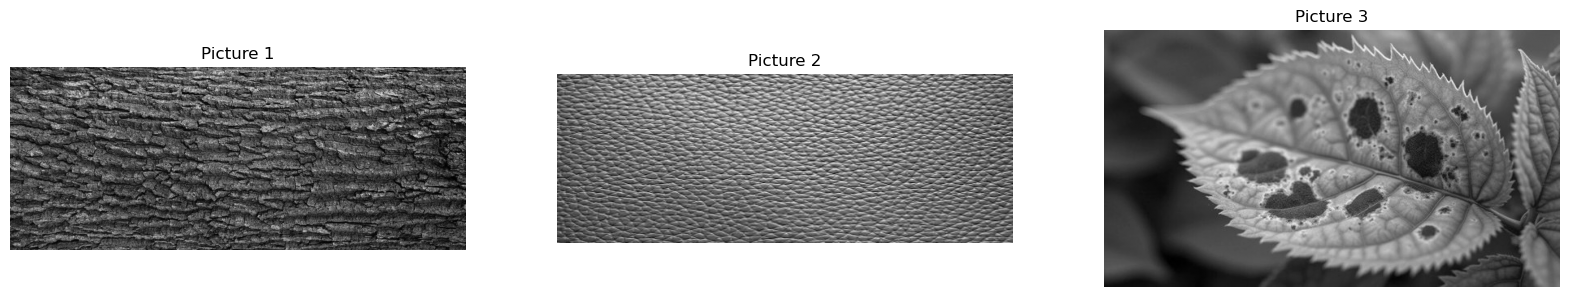

In [30]:
img1 = cv2.imread('../../../assets/Picture1.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('../../../assets/Picture2.jpg', cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread('../../../assets/Picture3.jpg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.imshow(img1, cmap='gray')
plt.title('Picture 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img2, cmap='gray')
plt.title('Picture 2')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img3, cmap='gray')
plt.title('Picture 3')
plt.axis('off')
plt.show()

In [ ]:
def plot_glcm(img, glcm1, glcm2, glcm3,title0, title1, title2, title3):
    plt.figure(figsize=(20, 16))

    ax0=plt.subplot(1, 4, 1)
    ax0.imshow(img, cmap='gray')
    ax0.set_title(title0)
    ax0.set_xlabel('X')
    ax0.set_ylabel('Y')

    ax1 = plt.subplot(1, 4, 2)
    im1 = ax1.imshow(glcm1, cmap='hot', interpolation='nearest')
    ax1.set_title(title1)
    ax1.set_xlabel('Gray Level y')
    ax1.set_ylabel('Gray Level x')
    plt.colorbar(im1, ax=ax1, fraction=0.05, pad=0.05, label='Probability')

    ax2 = plt.subplot(1, 4, 3)
    im2 = ax2.imshow(glcm2, cmap='hot', interpolation='nearest')
    ax2.set_title(title2)
    ax2.set_xlabel('Gray Level y')
    ax2.set_ylabel('Gray Level x')
    plt.colorbar(im2, ax=ax2, fraction=0.05, pad=0.05, label='Probability')

    ax3 = plt.subplot(1, 4, 4)
    im3 = ax3.imshow(glcm3, cmap='hot', interpolation='nearest')
    ax3.set_title(title3)
    ax3.set_xlabel('Gray Level y')
    ax3.set_ylabel('Gray Level x')
    plt.colorbar(im3, ax=ax3, fraction=0.05, pad=0.05, label='Probability')

    plt.tight_layout()
    plt.show()

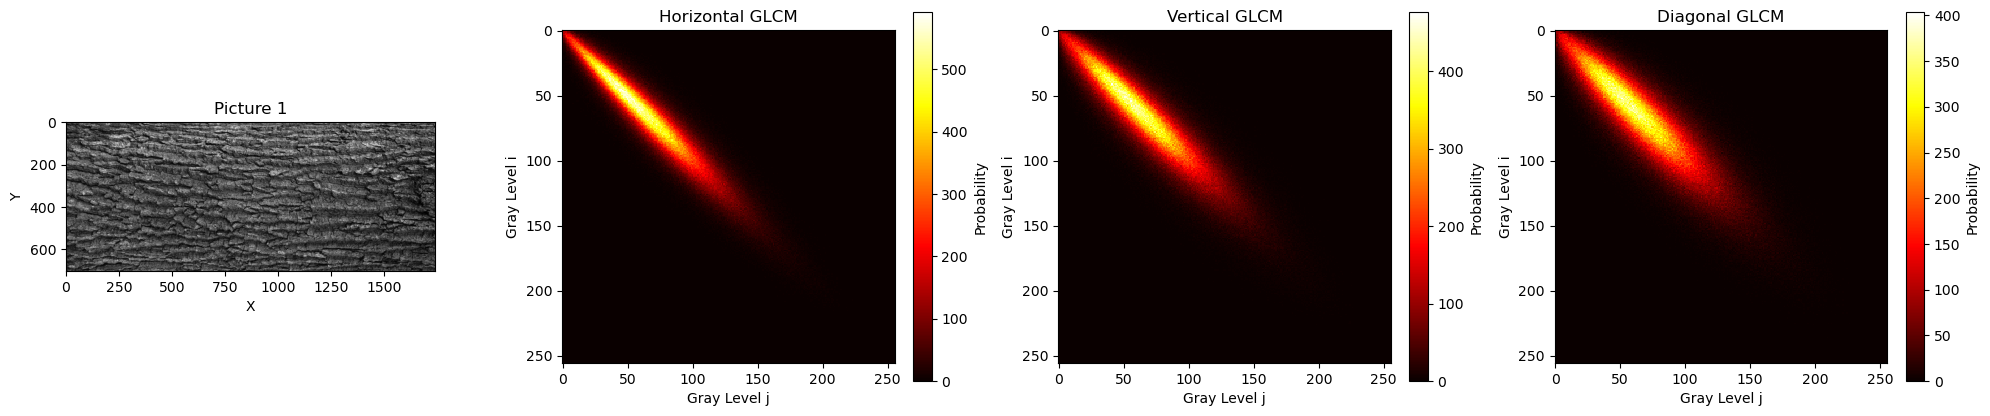

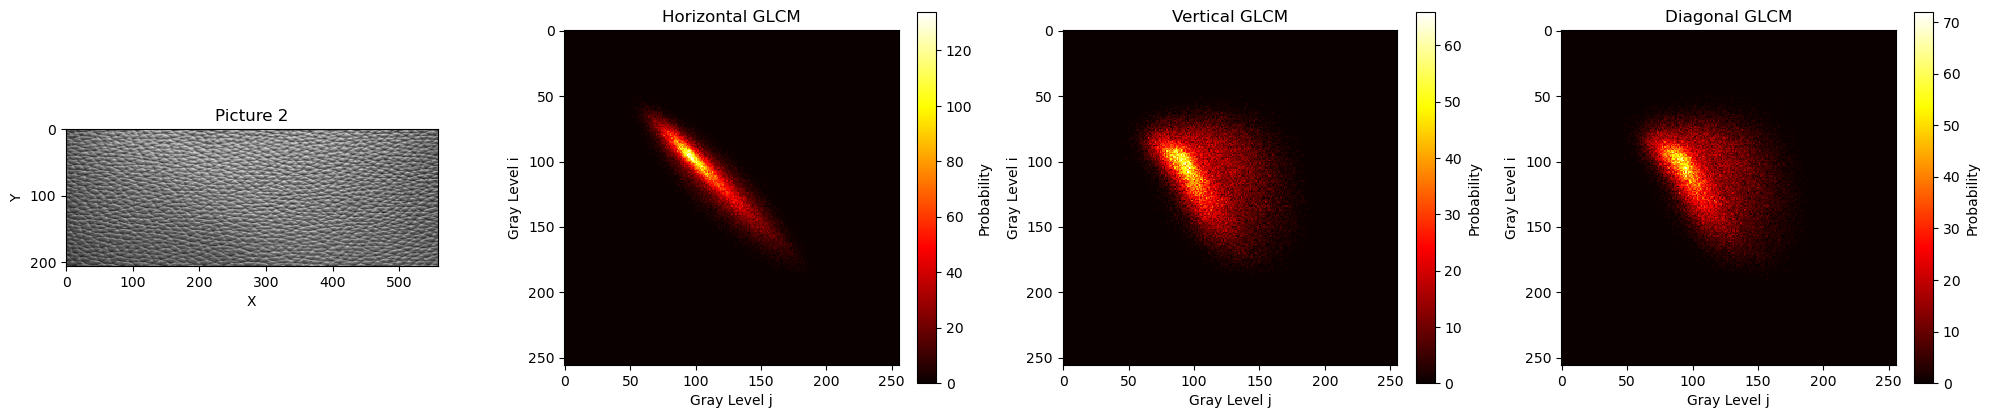

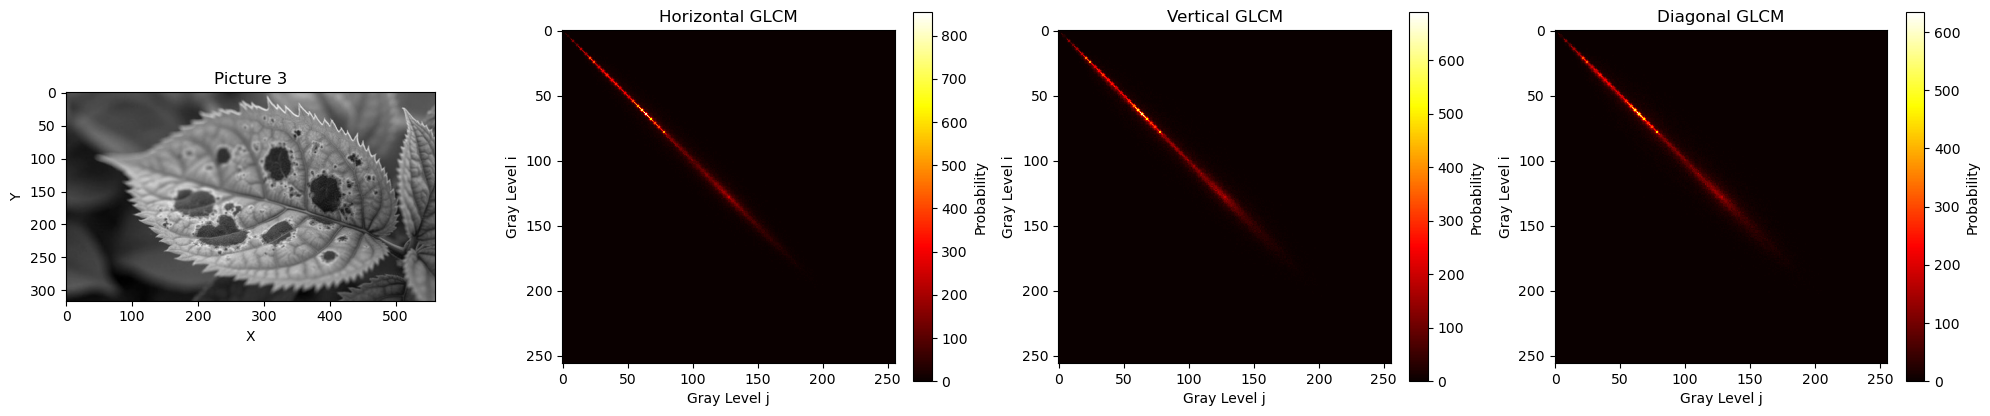

In [32]:
hor_glcm_1 = glcm_x(img1)
ver_glcm_1 = glcm_y(img1)
diag_glcm_1 = glcm_xy(img1)
plot_glcm(img1, hor_glcm_1, ver_glcm_1, diag_glcm_1, 'Picture 1', 'Horizontal GLCM', 'Vertical GLCM', 'Diagonal GLCM')

hor_glcm_2 = glcm_x(img2)
ver_glcm_2 = glcm_y(img2)
diag_glcm_2 = glcm_xy(img2)
plot_glcm(img2, hor_glcm_2, ver_glcm_2, diag_glcm_2, 'Picture 2', 'Horizontal GLCM', 'Vertical GLCM', 'Diagonal GLCM')

hor_glcm_3 = glcm_x(img3)
ver_glcm_3 = glcm_y(img3)
diag_glcm_3 = glcm_xy(img3)
plot_glcm(img3, hor_glcm_3, ver_glcm_3, diag_glcm_3, 'Picture 3', 'Horizontal GLCM', 'Vertical GLCM', 'Diagonal GLCM')

In [ ]:
def print_glcm_features(image, glcm, direction):
    print(f"GLCM Features for {direction} direction:")
    print(f"Maximal Probability: {max_probability(glcm)}")
    print(f"Energy: {energy(glcm)}")
    print(f"Entropy: {entropy(glcm)}")
    print(f"Contrast: {contrast(glcm)}")
    print(f"Homogeneity: {homogenity(glcm)}")
    print("\n")
    
print_glcm_features(img1, hor_glcm_1, "Horizontal")
print_glcm_features(img1, ver_glcm_1, "Vertical")
print_glcm_features(img1, diag_glcm_1, "Diagonal")
print_glcm_features(img2, hor_glcm_2, "Horizontal")
print_glcm_features(img2, ver_glcm_2, "Vertical")
print_glcm_features(img2, diag_glcm_2, "Diagonal")
print_glcm_features(img3, hor_glcm_3, "Horizontal")
print_glcm_features(img3, ver_glcm_3, "Vertical")
print_glcm_features(img3, diag_glcm_3, "Diagonal")


GLCM Features for Horizontal direction:
Maximal Probability: 0.00048410151739658057
Energy: 0.00021865308275021163
Entropy: 12.664886688720898
Contrast: 0.0
Homogeneity: 0.0


GLCM Features for Vertical direction:
Maximal Probability: 0.000390393855839089
Energy: 0.00016876689768914908
Entropy: 13.023349413599883
Contrast: 0.0
Homogeneity: 0.0


GLCM Features for Diagonal direction:
Maximal Probability: 0.0003308378550569876
Energy: 0.00014299918780487285
Entropy: 13.240873907595294
Contrast: 0.0
Homogeneity: 0.0


GLCM Features for Horizontal direction:
Maximal Probability: 0.0011678374091439927
Energy: 0.0003648848376614363
Entropy: 11.939344296878858
Contrast: 0.0
Homogeneity: 0.0


GLCM Features for Vertical direction:
Maximal Probability: 0.0005769735116706006
Energy: 0.00017051186137522316
Entropy: 12.95248195166118
Contrast: 0.0
Homogeneity: 0.0


GLCM Features for Diagonal direction:
Maximal Probability: 0.0006305556771905241
Energy: 0.0001720856063016559
Entropy: 12.9424764799